# 03 特征筛选模块 (core.selectors)

提供多种特征筛选方法，包括过滤法、包装法、嵌入法。

**筛选方法分类**

- **过滤法**: 方差、相关性、VIF、缺失率、单一值率、基数、IV、Lift、PSI
- **包装法**: RFE递归消除、逐步回归、Boruta
- **嵌入法**: 特征重要性、Lasso、树模型重要性、Null Importance、Mutual Info、卡方、F检验

**数据说明**: 基于 `hscredit_yyp.xlsx`，目标变量为 `MOB1 > 3`

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit import init_setting
from hscredit.core.selectors import (
    VarianceSelector, NullSelector, ModeSelector, CorrSelector, VIFSelector,
    IVSelector, LiftSelector, PSISelector, CardinalitySelector,
    TypeSelector, RegexSelector,
    FeatureImportanceSelector, NullImportanceSelector, RFESelector,
    SequentialFeatureSelector, StepwiseSelector, BorutaSelector,
    MutualInfoSelector, Chi2Selector, FTestSelector,
    CompositeFeatureSelector, StabilityAwareSelector,
)

init_setting()

df = pd.read_excel('hscredit_yyp.xlsx')
df['target'] = (df['MOB1'] > 3).astype(int)

numeric_features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3',
                   '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']

df_model = df[numeric_features + ['target']].copy()
df_model = df_model.dropna()

print(f"样本数: {len(df_model):,}")
print(f"特征数: {len(numeric_features)}")
print(f"坏样本率: {df_model['target'].mean():.2%}")

样本数: 264
特征数: 8
坏样本率: 14.02%


## 1. 过滤法 - 基础筛选

### 1.1 方差筛选 (VarianceSelector)

In [3]:
# 方差筛选 - 移除方差过低的特征
var_selector = VarianceSelector(threshold=0.01)
var_selector.fit(df_model[numeric_features])

print("=== 方差筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(var_selector.selected_features_)}")
print(f"剔除特征: {var_selector.removed_features_}")

print("\n各特征方差:")
for feat, var in zip(var_selector.feature_names_in_, var_selector.scores_):
    status = "保留" if feat in var_selector.selected_features_ else "剔除"
    print(f"  {feat}: {var:.4f} ({status})")

=== 方差筛选结果 ===
原始特征数: 8
保留特征数: 6
剔除特征: ['轻花老客海纳子分V1', '衡枢鉴真分老客版']

各特征方差:
  中智小牛分C3: 8562.1923 (保留)
  珊瑚92: 4929.5799 (保留)
  极光欺诈分6v1: 0.0572 (保留)
  青云24: 2582.7044 (保留)
  占信V3: 3170.5492 (保留)
  轻花老客海纳子分V1: 0.0015 (剔除)
  天创小额网贷分: 1985.9468 (保留)
  衡枢鉴真分老客版: 0.0017 (剔除)


### 1.2 缺失率筛选 (NullSelector)

In [4]:
# 缺失率筛选 - 移除缺失率过高的特征
# 注意：df_model已dropna，这里用原df演示
null_selector = NullSelector(threshold=0.5)
null_selector.fit(df[numeric_features])

print("=== 缺失率筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(null_selector.selected_features_)}")
print(f"剔除特征: {null_selector.removed_features_}")

print("\n各特征缺失率:")
for feat, null_rate in zip(null_selector.feature_names_in_, null_selector.scores_):
    status = "保留" if feat in null_selector.selected_features_ else "剔除"
    print(f"  {feat}: {null_rate:.2%} ({status})")

=== 缺失率筛选结果 ===
原始特征数: 8
保留特征数: 5
剔除特征: ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1']

各特征缺失率:
  中智小牛分C3: 68.35% (剔除)
  珊瑚92: 72.78% (剔除)
  极光欺诈分6v1: 68.25% (剔除)
  青云24: 0.00% (保留)
  占信V3: 0.52% (保留)
  轻花老客海纳子分V1: 3.30% (保留)
  天创小额网贷分: 0.00% (保留)
  衡枢鉴真分老客版: 0.00% (保留)


### 1.3 单一值率筛选 (ModeSelector)

In [5]:
# 单一值率筛选 - 移除单一值占比过高的特征
mode_selector = ModeSelector(threshold=0.95)
mode_selector.fit(df_model[numeric_features])

print("=== 单一值率筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(mode_selector.selected_features_)}")

print("\n各特征单一值率:")
for feat, mode_rate in zip(mode_selector.feature_names_in_, mode_selector.scores_):
    status = "保留" if feat in mode_selector.selected_features_ else "剔除"
    print(f"  {feat}: {mode_rate:.2%} ({status})")

=== 单一值率筛选结果 ===
原始特征数: 8
保留特征数: 8

各特征单一值率:
  中智小牛分C3: 2.27% (保留)
  珊瑚92: 2.65% (保留)
  极光欺诈分6v1: 5.68% (保留)
  青云24: 1.89% (保留)
  占信V3: 2.27% (保留)
  轻花老客海纳子分V1: 0.38% (保留)
  天创小额网贷分: 3.03% (保留)
  衡枢鉴真分老客版: 0.38% (保留)


### 1.4 类型筛选 (TypeSelector)

In [6]:
# 类型筛选 - 仅保留指定数据类型的特征
type_selector = TypeSelector(include=['number'])
type_selector.fit(df_model[numeric_features])

print("=== 类型筛选结果 ===")
print(f"保留特征数: {len(type_selector.selected_features_)}")
print(f"保留特征: {type_selector.selected_features_}")

=== 类型筛选结果 ===
保留特征数: 8
保留特征: ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']


### 1.5 正则筛选 (RegexSelector)

In [7]:
# 正则筛选 - 按列名正则表达式筛选
regex_selector = RegexSelector(pattern=r'^[^_]+$',  # 不含下划线的列名
                             flags=0)
regex_selector.fit(df_model[numeric_features])

print("=== 正则筛选结果 ===")
print(f"保留特征数: {len(regex_selector.selected_features_)}")
print(f"保留特征: {regex_selector.selected_features_}")

=== 正则筛选结果 ===
保留特征数: 8
保留特征: ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']


### 1.6 基数筛选 (CardinalitySelector)

In [8]:
# 基数筛选 - 移除基数过高或过低的特征
card_selector = CardinalitySelector(threshold=50)
card_selector.fit(df_model[numeric_features])

print("=== 基数筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(card_selector.selected_features_)}")

print("\n各特征基数:")
for feat, card in zip(card_selector.feature_names_in_, card_selector.scores_):
    status = "保留" if feat in card_selector.selected_features_ else "剔除"
    print(f"  {feat}: {int(card)} ({status})")

=== 基数筛选结果 ===
原始特征数: 8
保留特征数: 1

各特征基数:
  中智小牛分C3: 187 (剔除)
  珊瑚92: 158 (剔除)
  极光欺诈分6v1: 41 (保留)
  青云24: 143 (剔除)
  占信V3: 149 (剔除)
  轻花老客海纳子分V1: 264 (剔除)
  天创小额网贷分: 101 (剔除)
  衡枢鉴真分老客版: 264 (剔除)


## 2. 过滤法 - 相关性筛选

### 2.1 相关性筛选 (CorrSelector)

In [9]:
# 相关性筛选
corr_selector = CorrSelector(threshold=0.95)
corr_selector.fit(df_model[numeric_features])

print("=== 相关性筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(corr_selector.selected_features_)}")
print(f"剔除特征: {corr_selector.removed_features_}")

# 高相关性特征对
print("\n高相关性特征对 (|r| > 0.95):")
corr_matrix = df_model[numeric_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.95]
if high_corr:
    for pair in high_corr:
        print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.4f}")
else:
    print("  无高相关性特征对")

=== 相关性筛选结果 ===
原始特征数: 8
保留特征数: 8
剔除特征: []

高相关性特征对 (|r| > 0.95):
  无高相关性特征对


### 2.2 VIF筛选 (VIFSelector)

In [10]:
# VIF筛选
vif_selector = VIFSelector(threshold=10.0)
vif_selector.fit(df_model[numeric_features])

print("=== VIF筛选结果 ===")
print(f"保留特征数: {len(vif_selector.selected_features_)}")

print("\n各特征VIF值:")
for feat, vif in zip(vif_selector.feature_names_in_, vif_selector.scores_):
    status = "保留" if feat in vif_selector.selected_features_ else "剔除"
    print(f"  {feat}: {vif:.2f} ({status})")

=== VIF筛选结果 ===
保留特征数: 8

各特征VIF值:
  中智小牛分C3: 1.17 (保留)
  珊瑚92: 1.00 (保留)
  极光欺诈分6v1: 1.07 (保留)
  青云24: 1.09 (保留)
  占信V3: 1.07 (保留)
  轻花老客海纳子分V1: 1.17 (保留)
  天创小额网贷分: 1.00 (保留)
  衡枢鉴真分老客版: 1.16 (保留)


## 3. 过滤法 - 目标导向筛选

### 3.1 IV筛选 (IVSelector)

In [11]:
# IV筛选
iv_selector = IVSelector(threshold=0.02)
iv_selector.fit(df_model[numeric_features], df_model['target'])

print("=== IV筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(iv_selector.selected_features_)}")

print("\n各特征IV值:")
iv_df = pd.DataFrame({
    '特征': iv_selector.feature_names_in_,
    'IV': iv_selector.scores_
}).sort_values('IV', ascending=False)

for _, row in iv_df.iterrows():
    level = "强" if row['IV'] > 0.3 else "中" if row['IV'] > 0.1 else "弱" if row['IV'] > 0.02 else "无"
    status = "保留" if row['特征'] in iv_selector.selected_features_ else "剔除"
    print(f"  {row['特征']}: {row['IV']:.4f} ({level}预测力, {status})")

=== IV筛选结果 ===
原始特征数: 8
保留特征数: 6

各特征IV值:
  青云24: 1.9777 (强预测力, 保留)
  占信V3: 1.8703 (强预测力, 保留)
  中智小牛分C3: 1.8631 (强预测力, 保留)
  珊瑚92: 1.7751 (强预测力, 保留)
  天创小额网贷分: 1.4895 (强预测力, 保留)
  极光欺诈分6v1: 0.7212 (强预测力, 保留)
  轻花老客海纳子分V1: 0.0000 (无预测力, 剔除)
  衡枢鉴真分老客版: 0.0000 (无预测力, 剔除)


### 3.2 Lift筛选 (LiftSelector)

In [12]:
# Lift筛选
lift_selector = LiftSelector(threshold=1.5, ratio=0.1)
lift_selector.fit(df_model[numeric_features], df_model['target'])

print("=== Lift筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(lift_selector.selected_features_)}")

print("\n各特征Lift值:")
for feat, lift in zip(lift_selector.feature_names_in_, lift_selector.scores_):
    status = "保留" if feat in lift_selector.selected_features_ else "剔除"
    print(f"  {feat}: {lift:.4f} ({status})")

=== Lift筛选结果 ===
原始特征数: 8
保留特征数: 0

各特征Lift值:
  中智小牛分C3: 0.8498 (剔除)
  珊瑚92: 0.5856 (剔除)
  极光欺诈分6v1: 0.8498 (剔除)
  青云24: 0.8498 (剔除)
  占信V3: 0.4715 (剔除)
  轻花老客海纳子分V1: 1.1141 (剔除)
  天创小额网贷分: 0.3213 (剔除)
  衡枢鉴真分老客版: 0.4715 (剔除)


### 3.3 PSI筛选 (PSISelector)

In [13]:
# PSI筛选 - 使用两部分数据模拟稳定性筛选
# 将数据分为两部分，检验特征的稳定性
df_part1 = df_model.iloc[:int(len(df_model) * 0.6)]
df_part2 = df_model.iloc[int(len(df_model) * 0.6):]

psi_selector = PSISelector(threshold=0.2)
psi_selector.fit(df_part1[numeric_features], df_part2[numeric_features])

print("=== PSI筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(psi_selector.selected_features_)}")

print("\n各特征PSI值:")
for feat, psi_val in zip(psi_selector.feature_names_in_, psi_selector.scores_):
    level = "稳定" if psi_val < 0.1 else "轻微漂移" if psi_val < 0.2 else "显著漂移"
    status = "保留" if feat in psi_selector.selected_features_ else "剔除"
    print(f"  {feat}: {psi_val:.4f} ({level}, {status})")

=== PSI筛选结果 ===
原始特征数: 8
保留特征数: 0

各特征PSI值:
  中智小牛分C3: 0.4707 (显著漂移, 剔除)
  珊瑚92: 0.3016 (显著漂移, 剔除)
  极光欺诈分6v1: 0.2660 (显著漂移, 剔除)
  青云24: 0.2317 (显著漂移, 剔除)
  占信V3: 0.3968 (显著漂移, 剔除)
  轻花老客海纳子分V1: 0.3663 (显著漂移, 剔除)
  天创小额网贷分: 0.3225 (显著漂移, 剔除)
  衡枢鉴真分老客版: 0.3846 (显著漂移, 剔除)


## 4. 嵌入法 - 特征重要性筛选

### 4.1 特征重要性筛选 (FeatureImportanceSelector)

=== 特征重要性筛选结果 ===
原始特征数: 8
保留特征数: 8


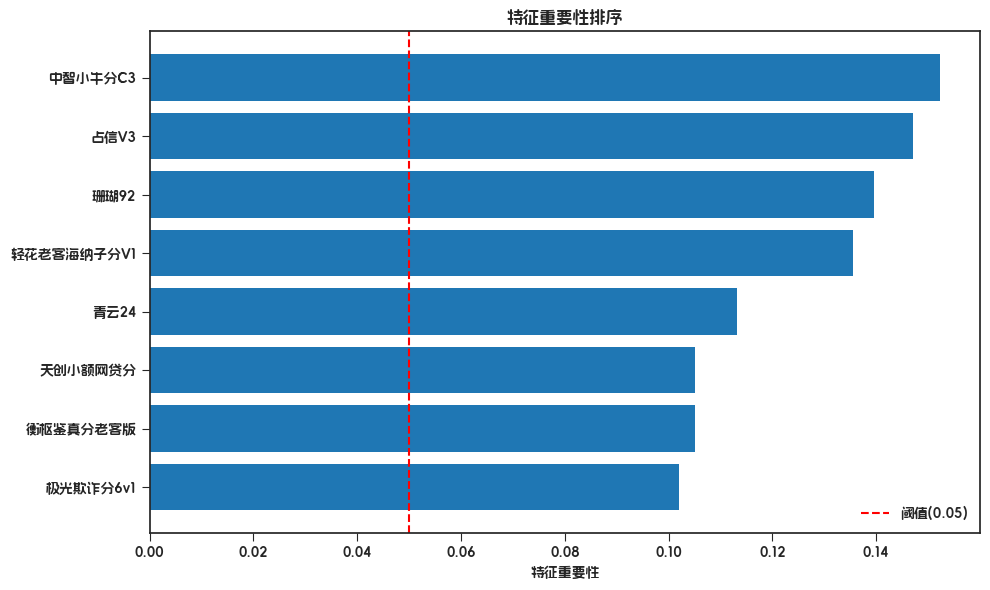

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 特征重要性筛选
imp_selector = FeatureImportanceSelector(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    threshold=0.05,  # 保留重要性 >= 0.05的特征
)
imp_selector.fit(df_model[numeric_features], df_model['target'])

print("=== 特征重要性筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(imp_selector.selected_features_)}")

# 可视化
importance_df = pd.DataFrame({
    '特征': imp_selector.feature_names_in_,
    '重要性': imp_selector.scores_
}).sort_values('重要性', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['特征'], importance_df['重要性'])
plt.axvline(x=0.05, color='red', linestyle='--', label='阈值(0.05)')
plt.xlabel('特征重要性')
plt.title('特征重要性排序')
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Null Importance筛选 (NullImportanceSelector)

In [15]:
from hscredit import XGBoostRiskModel
# Null Importance筛选 - 对比真实重要性与随机打乱后的重要性
null_imp_selector = NullImportanceSelector(
    estimator=RandomForestClassifier(n_estimators=30, random_state=42),
    # estimator=XGBoostRiskModel(max_depth=5, learning_rate=0.1),
    threshold=1.0,  # 真实重要性/随机重要性 > 1.0 才保留
    cv=2, n_runs=2  # 交叉验证次数
)
null_imp_selector.fit(df_model[numeric_features], df_model['target'])

print("=== Null Importance筛选结果 ===")
print(f"保留特征数: {len(null_imp_selector.selected_features_)}")

print("\n各特征Null Importance:")
for feat, imp in zip(null_imp_selector.feature_names_in_, null_imp_selector.scores_):
    status = "保留" if feat in null_imp_selector.selected_features_ else "剔除"
    print(f"  {feat}: {imp:.4f} ({status})")

=== Null Importance筛选结果 ===
保留特征数: 3

各特征Null Importance:
  中智小牛分C3: 1.1969 (保留)
  珊瑚92: 1.1281 (保留)
  极光欺诈分6v1: 0.9940 (剔除)
  青云24: 1.0904 (保留)
  占信V3: 0.8189 (剔除)
  轻花老客海纳子分V1: 0.9733 (剔除)
  天创小额网贷分: 0.9078 (剔除)
  衡枢鉴真分老客版: 0.9282 (剔除)


### 4.3 Mutual Info筛选 (MutualInfoSelector)

In [16]:
# 互信息筛选
mi_selector = MutualInfoSelector(threshold=0.02)
mi_selector.fit(df_model[numeric_features], df_model['target'])

print("=== 互信息筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(mi_selector.selected_features_)}")

print("\n各特征互信息:")
for feat, mi in zip(mi_selector.feature_names_in_, mi_selector.scores_):
    status = "保留" if feat in mi_selector.selected_features_ else "剔除"
    print(f"  {feat}: {mi:.4f} ({status})")

=== 互信息筛选结果 ===
原始特征数: 8
保留特征数: 2

各特征互信息:
  中智小牛分C3: 0.0224 (保留)
  珊瑚92: 0.0207 (保留)
  极光欺诈分6v1: 0.0000 (剔除)
  青云24: 0.0140 (剔除)
  占信V3: 0.0102 (剔除)
  轻花老客海纳子分V1: 0.0169 (剔除)
  天创小额网贷分: 0.0000 (剔除)
  衡枢鉴真分老客版: 0.0000 (剔除)


### 4.4 卡方筛选 (Chi2Selector)

In [17]:
# 卡方筛选 - 需要非负特征值
# 将特征归一化到非负区间
X_chi = df_model[numeric_features].copy()
X_chi = (X_chi - X_chi.min()) / (X_chi.max() - X_chi.min() + 1e-10)  # 归一化到 [0,1]

chi2_selector = Chi2Selector(k=4)  # 保留得分最高的前4个
chi2_selector.fit(X_chi, df_model['target'])

print("=== 卡方筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(chi2_selector.selected_features_)}")
print(f"保留特征: {chi2_selector.selected_features_}")

print("\n各特征卡方得分:")
for feat, score in zip(chi2_selector.feature_names_in_, chi2_selector.scores_):
    print(f"  {feat}: {score:.4f}")

=== 卡方筛选结果 ===
原始特征数: 8
保留特征数: 4
保留特征: ['青云24', '极光欺诈分6v1', '中智小牛分C3', '轻花老客海纳子分V1']

各特征卡方得分:
  中智小牛分C3: 1.1427
  珊瑚92: 0.1091
  极光欺诈分6v1: 0.7752
  青云24: 0.4396
  占信V3: 0.4170
  轻花老客海纳子分V1: 2.2406
  天创小额网贷分: 0.0014
  衡枢鉴真分老客版: 0.1954


### 4.5 F检验筛选 (FTestSelector)

In [18]:
# F检验筛选
f_test_selector = FTestSelector(k=4)
f_test_selector.fit(df_model[numeric_features], df_model['target'])

print("=== F检验筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(f_test_selector.selected_features_)}")

print("\n各特征F检验得分:")
for feat, score in zip(f_test_selector.feature_names_in_, f_test_selector.scores_):
    print(f"  {feat}: {score:.4f}")

=== F检验筛选结果 ===
原始特征数: 8
保留特征数: 4

各特征F检验得分:
  中智小牛分C3: 8.9107
  珊瑚92: 1.6757
  极光欺诈分6v1: 3.4533
  青云24: 5.3704
  占信V3: 7.7827
  轻花老客海纳子分V1: 12.0300
  天创小额网贷分: 0.0213
  衡枢鉴真分老客版: 1.4040


## 5. 包装法

### 5.1 RFESelector (支持所有hscredit模型)


In [ ]:
# 5.2 RFESelector - 递归特征消除
from hscredit.core.selectors import RFESelector

results_rfe = {}

for name, model in all_models.items():
    try:
        # 对于逻辑回归需要标准化
        if name == "LogisticRegression":
            from sklearn.preprocessing import StandardScaler
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            X_use = X_scaled
        else:
            X_use = X
        
        selector = RFESelector(
            estimator=model,
            n_features_to_select=5,
            step=1,
        )
        selector.fit(X_use, y)
        results_rfe[name] = selector.selected_features_
        print(f"RFESelector + {name}: {selector.selected_features_}")
    except Exception as e:
        print(f"RFESelector + {name}: Error - {e}")


### 5.2 SequentialFeatureSelector (支持所有hscredit模型)


In [ ]:
# 5.3 SequentialFeatureSelector - 序列前向/后向选择
from hscredit.core.selectors import SequentialFeatureSelector

results_sfs = {}

for name, model in all_models.items():
    try:
        if name == "LogisticRegression":
            X_use = X_scaled
        else:
            X_use = X
        
        selector = SequentialFeatureSelector(
            estimator=model,
            n_features_to_select=5,
            direction='forward',
            cv=3,
        )
        selector.fit(X_use, y)
        results_sfs[name] = selector.selected_features_
        print(f"SequentialFeatureSelector + {name}: {selector.selected_features_}")
    except Exception as e:
        print(f"SequentialFeatureSelector + {name}: Error - {e}")


### 5.3 FeatureImportanceSelector (支持所有hscredit模型)


In [ ]:
# 5.4 FeatureImportanceSelector - 基于重要性阈值筛选
from hscredit.core.selectors import FeatureImportanceSelector

results_fis = {}

for name, model in all_models.items():
    try:
        selector = FeatureImportanceSelector(
            estimator=model,
            threshold=0.05,
        )
        selector.fit(X, y)
        results_fis[name] = selector.selected_features_
        print(f"FeatureImportanceSelector + {name}: {selector.selected_features_}")
    except Exception as e:
        print(f"FeatureImportanceSelector + {name}: Error - {e}")


### 5.4 BorutaSelector (支持所有hscredit模型)


In [ ]:
# 5.5 BorutaSelector - 基于统计显著性筛选
from hscredit.core.selectors import BorutaSelector

results_boruta = {}

tree_models = [
    ("RandomForestRiskModel", RandomForestRiskModel(n_estimators=50, random_state=42)),
    ("ExtraTreesRiskModel", ExtraTreesRiskModel(n_estimators=50, random_state=42)),
    ("GradientBoostingRiskModel", GradientBoostingRiskModel(n_estimators=50, random_state=42)),
]

try:
    import catboost
    tree_models.append(("CatBoostRiskModel", CatBoostRiskModel(iterations=50, random_state=42, verbose=False)))
except ImportError:
    print("CatBoost not available, skipping...")

for name, model in tree_models:
    try:
        selector = BorutaSelector(
            estimator=model,
            n_iter=10,
            random_state=42,
        )
        selector.fit(X, y)
        results_boruta[name] = selector.selected_features_
        print(f"BorutaSelector + {name}: {selector.selected_features_}")
    except Exception as e:
        print(f"BorutaSelector + {name}: Error - {e}")


### 5.5 StepwiseSelector (支持自定义sklearn风格评估器)


In [ ]:
# 5.6 StepwiseSelector - 逐步回归筛选
from hscredit.core.selectors import StepwiseSelector

# 方法1: statsmodels逻辑回归
import statsmodels.api as sm
logit_model = sm.Logit(y, sm.add_constant(X))
selector1 = StepwiseSelector(
    estimator='logit',
    direction='forward',
    criterion='aic',
    max_iter=10,
)
selector1.fit(X, y)
print(f"StepwiseSelector (statsmodels logit): {selector1.selected_features_}")

# 方法2: sklearn逻辑回归
from sklearn.linear_model import LogisticRegression as SklearnLR
selector2 = StepwiseSelector(
    estimator=SklearnLR(max_iter=1000, random_state=42),
    direction='forward',
    criterion='aic',
    scoring='neg_log_loss',
)
selector2.fit(X_scaled, y)
print(f"StepwiseSelector (sklearn LR): {selector2.selected_features_}")

# 方法3: hscredit随机森林
selector3 = StepwiseSelector(
    estimator=RandomForestRiskModel(n_estimators=50, random_state=42),
    direction='backward',
    criterion='aic',
    scoring='neg_log_loss',
)
selector3.fit(X, y)
print(f"StepwiseSelector (RandomForest): {selector3.selected_features_}")


In [27]:
# 稳定性感知筛选 - 在bootstrap样本上评估特征选择的稳定性
stab_selector = StabilityAwareSelector(
    # estimator=RandomForestClassifier(n_estimators=30, random_state=42),
    # n_bootstrap=10,
    # threshold=0.6  # 保留在60%以上bootstrap中被选中的特征
)
stab_selector.fit(df_model[numeric_features], df_model['target'])

print("=== 稳定性感知筛选结果 ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"保留特征数: {len(stab_selector.selected_features_)}")

print("\n各特征选择稳定性:")
for feat, stab in zip(stab_selector.feature_names_in_, stab_selector.scores_):
    status = "保留" if feat in stab_selector.selected_features_ else "剔除"
    print(f"  {feat}: {stab:.2%} ({status})")

=== 稳定性感知筛选结果 ===
原始特征数: 8
保留特征数: 5

各特征选择稳定性:
  中智小牛分C3: 24.48% (保留)
  珊瑚92: 15.36% (保留)
  极光欺诈分6v1: -1.70% (剔除)
  青云24: 17.96% (保留)
  占信V3: -2.23% (剔除)
  轻花老客海纳子分V1: 20.00% (剔除)
  天创小额网贷分: 9.94% (保留)
  衡枢鉴真分老客版: 45.97% (保留)


## 6. 组合筛选

### Sequential组合筛选

In [28]:
# 组合筛选 - Sequential策略（逐个应用筛选器）
composite_selector = CompositeFeatureSelector(
    selectors=[
        IVSelector(threshold=0.02),      # 第一步：IV筛选
        CorrSelector(threshold=0.95),    # 第二步：相关性筛选
    ],
    strategy='sequential'
)

composite_selector.fit(df_model[numeric_features], df_model['target'])

print("=== 组合筛选结果 (Sequential) ===")
print(f"原始特征数: {len(numeric_features)}")
print(f"最终保留特征数: {len(composite_selector.selected_features_)}")
print(f"保留特征: {composite_selector.selected_features_}")

=== 组合筛选结果 (Sequential) ===
原始特征数: 8
最终保留特征数: 6
保留特征: ['中智小牛分C3', '占信V3', '青云24', '极光欺诈分6v1', '珊瑚92', '天创小额网贷分']


In [29]:
# 组合筛选 - Intersection策略（多个筛选器结果的交集）
composite_intersect = CompositeFeatureSelector(
    selectors=[
        IVSelector(threshold=0.02),
        FeatureImportanceSelector(
            estimator=RandomForestClassifier(n_estimators=50, random_state=42),
            threshold=0.03
        ),
    ],
    strategy='intersection'
)

composite_intersect.fit(df_model[numeric_features], df_model['target'])

print("=== 组合筛选结果 (Intersection) ===")
print(f"最终保留特征数: {len(composite_intersect.selected_features_)}")
print(f"保留特征: {composite_intersect.selected_features_}")

=== 组合筛选结果 (Intersection) ===
最终保留特征数: 6
保留特征: ['极光欺诈分6v1', '珊瑚92', '青云24', '天创小额网贷分', '中智小牛分C3', '占信V3']


## 7. 筛选结果汇总

In [30]:
# 6. 结果汇总
summary_data = []
for name in results_rfe:
    summary_data.append({
        'selector': 'RFESelector',
        'model': name,
        'features': ', '.join(results_rfe[name]),
        'count': len(results_rfe[name])
    })

for name in results_sfs:
    summary_data.append({
        'selector': 'SequentialFeatureSelector',
        'model': name,
        'features': ', '.join(results_sfs[name]),
        'count': len(results_sfs[name])
    })

for name in results_fis:
    summary_data.append({
        'selector': 'FeatureImportanceSelector',
        'model': name,
        'features': ', '.join(results_fis[name]),
        'count': len(results_fis[name])
    })

for name in results_boruta:
    summary_data.append({
        'selector': 'BorutaSelector',
        'model': name,
        'features': ', '.join(results_boruta[name]),
        'count': len(results_boruta[name])
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)


=== 各筛选方法结果对比 ===


,筛选方法,保留特征数,原始特征数,剔除特征数
0,方差筛选,6,8,2
1,缺失率筛选,5,8,3
2,单一值率筛选,8,8,0
3,相关性筛选,8,8,0
4,VIF筛选,8,8,0
5,IV筛选,6,8,2
6,Lift筛选,0,8,8
7,PSI筛选,0,8,8
8,基数筛选,1,8,7
9,类型筛选,8,8,0
